# Praktikum Big Data Analytics 1

**Aufgabe 1: Zahlzähler-Programm als Map-Reduce implementieren und Ausgaben als Histogramm plotten**

### Aufgabenstellung:

Schreiben Sie ein Programm, dass einen Zahlzähler als `Map-Reduce` mittels der entsprechenden Python-Funktionen implementiert. Dazu liest das Programm eine lokale Textdatei `P.csv` ein und gibt die Häufigkeit der einzelnen Zahlen tabellarisch aus. Nutzen Sie dazu die entsprechenden Python Funktionen! Stellen Sie dabei sicher, dass nur Zahlen erfasst werden - die Datei könnte Fehler beinhalten.

Zunächst importieren wir einige Bibliotheksfunktionen wie: `csv-` Umgang mit csv-Dateien, `defaultdict-` um leere Dictionarys initialisieren zu können, `reduce` aus `functools`, `pyplot` aus `matplotlib` zur Darstellung von Histogrammen

In [1]:
import csv
from collections import defaultdict
import functools
from tabulate import tabulate
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## mapper

Bei dieser funktion handelt es sich um die `mapper-` funktion, die in der `map()-` funktion aufgerufen wird.

In [2]:
# Mapping
def mapper(num):
    result = {} # leeres Dictionary
    result[num] = 1 # {Zahl:1}
    return result

## reducerForReduce

Hier definieren wir unsere `reduce-` funktion, die in der reduce Phase aufgerufen wird.

In [3]:
# Reducing 
def reducerForReduce(lhs, rhs):
    for k, v in rhs.items():  # falls das dict mehr als einen Eintrag hat.
        if k in lhs:
            lhs[k] += v
        else:
            lhs[k] = v
    return lhs

## filterNumericValues

Die funktion `filterNumericValues` filtert alle nicht Zahlen raus und gibt eine gefilterte Liste aus allen vorkommenden Zahlen aus

In [4]:
# filtere alle nicht zahlen
def filterNumericValues(numbers_list):
    filtered_list = []
    for num in numbers_list:
        try:
            int(num)
            filtered_list.append(num)
        except ValueError:
            pass
    return filtered_list

## MapReduceCountNumbers

Die Funktion `MapReduceCountNumbers` ist unsere aufrufbare MapReduce-Funktion, die den Zahlzähler als MapReduce mit den entsprechenden Funktionen implementiert. Die Funktion nimmt zwei Argumente entgegen: filename (der Name der CSV-Datei) und zahlen_dict (ein Python-Wörterbuch, das die gezählten Zahlen enthält).

Die Funktion liest die CSV-Datei mit Hilfe der `csv.reader Methode` ein und erstellt eine Liste mit allen numerischen Werten, die in der Datei gefunden werden.

Danach erstellen wir unsere `numbers_list` und fügen alle Zahlen, die in der csv-Datei vorgekommen, in die `numbers_list`. 

Im nächsten Schritt wird unsere `numbers_list` gefiltert. 

Anschließend wird die map phase mit der Funktion `map()` für jeden Schlüssel der Eingabedaten durchgeführt und schließlich wird die `functools.reduce-`Methode aufgerufen, um die gemappte Liste `mapped_numbers` in das Wörterbuch `zahlen_dict` zu reduzieren. Hierbei wird eine Reduktionsfunktion namens `reducerForReduce` aufgerufen, die die Anzahl der Vorkommen jeder Zahl zusammenfasst.

In [5]:
def MapReduceCountNumbers(filename, zahlen_dict):
    # Lese die CSV-Datei und führe die Map-Reduce-Funktion aus
    with open(filename, 'r') as csvfile:
        reader = csv.reader(csvfile, delimiter=';') # lese die CSV-Datei
        
        numbers_list = []
        for zellen_num in reader:
            for num in zellen_num:
                numbers_list.append(num)
        
        filtered_numbers = filterNumericValues(numbers_list) # gefilterte liste
        mapped_numbers = list(map(mapper, filtered_numbers)) # rufe Mapper auf
        zahlen_dict = functools.reduce(reducerForReduce, mapped_numbers, zahlen_dict) # rufe reduce-funktion auf

Aufruf der MapReduce-Funktion

In [6]:
zahlen_dict = defaultdict(int)
MapReduceCountNumbers('C:/FH Aachen/Big Data/Praktikum/P.csv', zahlen_dict)

## Tabellarische Darstellung von Daten

Hier wird eine Tabelle mit der Bibliotheksfunktion `tabulate` erstellt, indem eine Liste `table_data` erstellt wird, die aus Paaren von Schlüssel-Wert-Paaren des Wörterbuchs `zahlen_dict` besteht. Jedes Paar enthält eine Zahl und die Anzahl der Vorkommen dieser Zahl. Anschließend wird die Tabelle ausgegeben.

In [7]:
table_data = [[k, v] for k, v in zahlen_dict.items()]

headers = ["Zahl", "Häufigkeit"]
table = tabulate(table_data, headers=headers, tablefmt="grid")

print(table)

+--------+--------------+
|   Zahl |   Häufigkeit |
+========+==============+
|    -14 |          378 |
+--------+--------------+
|    -17 |          426 |
+--------+--------------+
|    -11 |          421 |
+--------+--------------+
|     70 |          315 |
+--------+--------------+
|    -12 |          394 |
+--------+--------------+
|   -149 |          126 |
+--------+--------------+
|     33 |          382 |
+--------+--------------+
|    -26 |          362 |
+--------+--------------+
|    -21 |          372 |
+--------+--------------+
|     11 |          408 |
+--------+--------------+
|     23 |          363 |
+--------+--------------+
|    116 |          203 |
+--------+--------------+
|     65 |          301 |
+--------+--------------+
|    -73 |          304 |
+--------+--------------+
|   -101 |          193 |
+--------+--------------+
|     24 |          370 |
+--------+--------------+
|    131 |          178 |
+--------+--------------+
|      4 |          359 |
+--------+--

## Plotten eines Histogramms

Hier wird ein Histogramm aus den Daten, die in `zahlen_dict` gespeichert sind, geplottet.

Zunächst werden die x- und y-Achsen des Histogramms in den Listen `x_axis` und `y_axis` erstellt.

Danach werden Titel und Beschriftungen für die x- und y-Achsen des Histogramms festgelegt.

Anschließend wird mit `bar()` das Histogramm geplottet.

<BarContainer object of 726 artists>

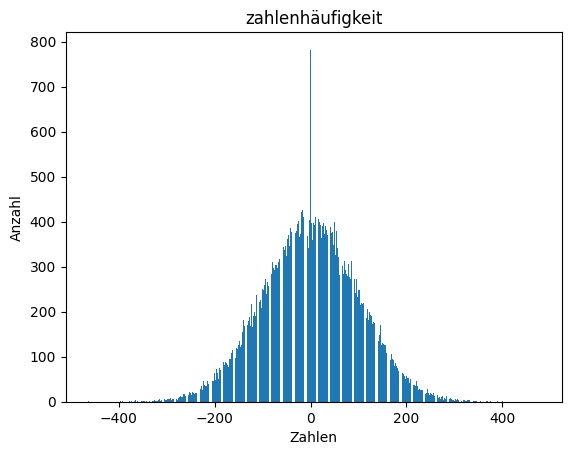

In [8]:
# Histogramm plotten
x_axis = [int(num) for num in zahlen_dict.keys()]
y_axis = [int(freq) for freq in zahlen_dict.values()]
plt.title('zahlenhäufigkeit')
plt.xlabel('Zahlen')
plt.ylabel('Anzahl')
plt.bar(x_axis,y_axis)